# Going to see the effect of Normalization on the model.

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
# Employee Performance Score Prediction

torch.manual_seed(42)
samples = 1000
weights = torch.Tensor([0.5, 0.9, 0.3, 0.4, 0.8]).unsqueeze(1)
bias = 0.4

attendance = torch.randint(60, 101, (samples, 1))          # Percentage # range(60 - 100)
experience = torch.randint(0, 11, (samples, 1))            # Years # range (0 - 10)
current_projects = torch.randint(1, 6, (samples, 1))       # range (1 - 5)
completed_projects = (experience  * 2) + torch.randint(1, 35, (samples, 1)) # range (1 - 34)
weekly_working_hours = torch.randint(30, 51, (samples, 1)) # range (30 - 50)

X = torch.concat((attendance, experience, current_projects, completed_projects, weekly_working_hours), dim=1).float()
noise = torch.randn(samples, 1) * 5  # noise level
y = torch.matmul(X, weights) + bias # + noise if you uncomment this line this current model accuracy will go down because of the current approach of loss function and optimzer we had used # Employee Performance Score
y = (y - y.min()) / (y.max() - y.min()) * 100
X[:10] , y[:10]
# ranges
# Attendance         : 60–100
# Experience         : 0–10
# Current Projects   : 1–5
# Completed Projects : 1–55
# Weekly Hours       : 30–50

In [ ]:
split_ratio = int(0.8 * len(X))

x_train, y_train = X[:split_ratio], y[:split_ratio]
x_test, y_test = X[split_ratio:], y[split_ratio:]

len(x_train), len(y_train), len(x_test), len(y_test)

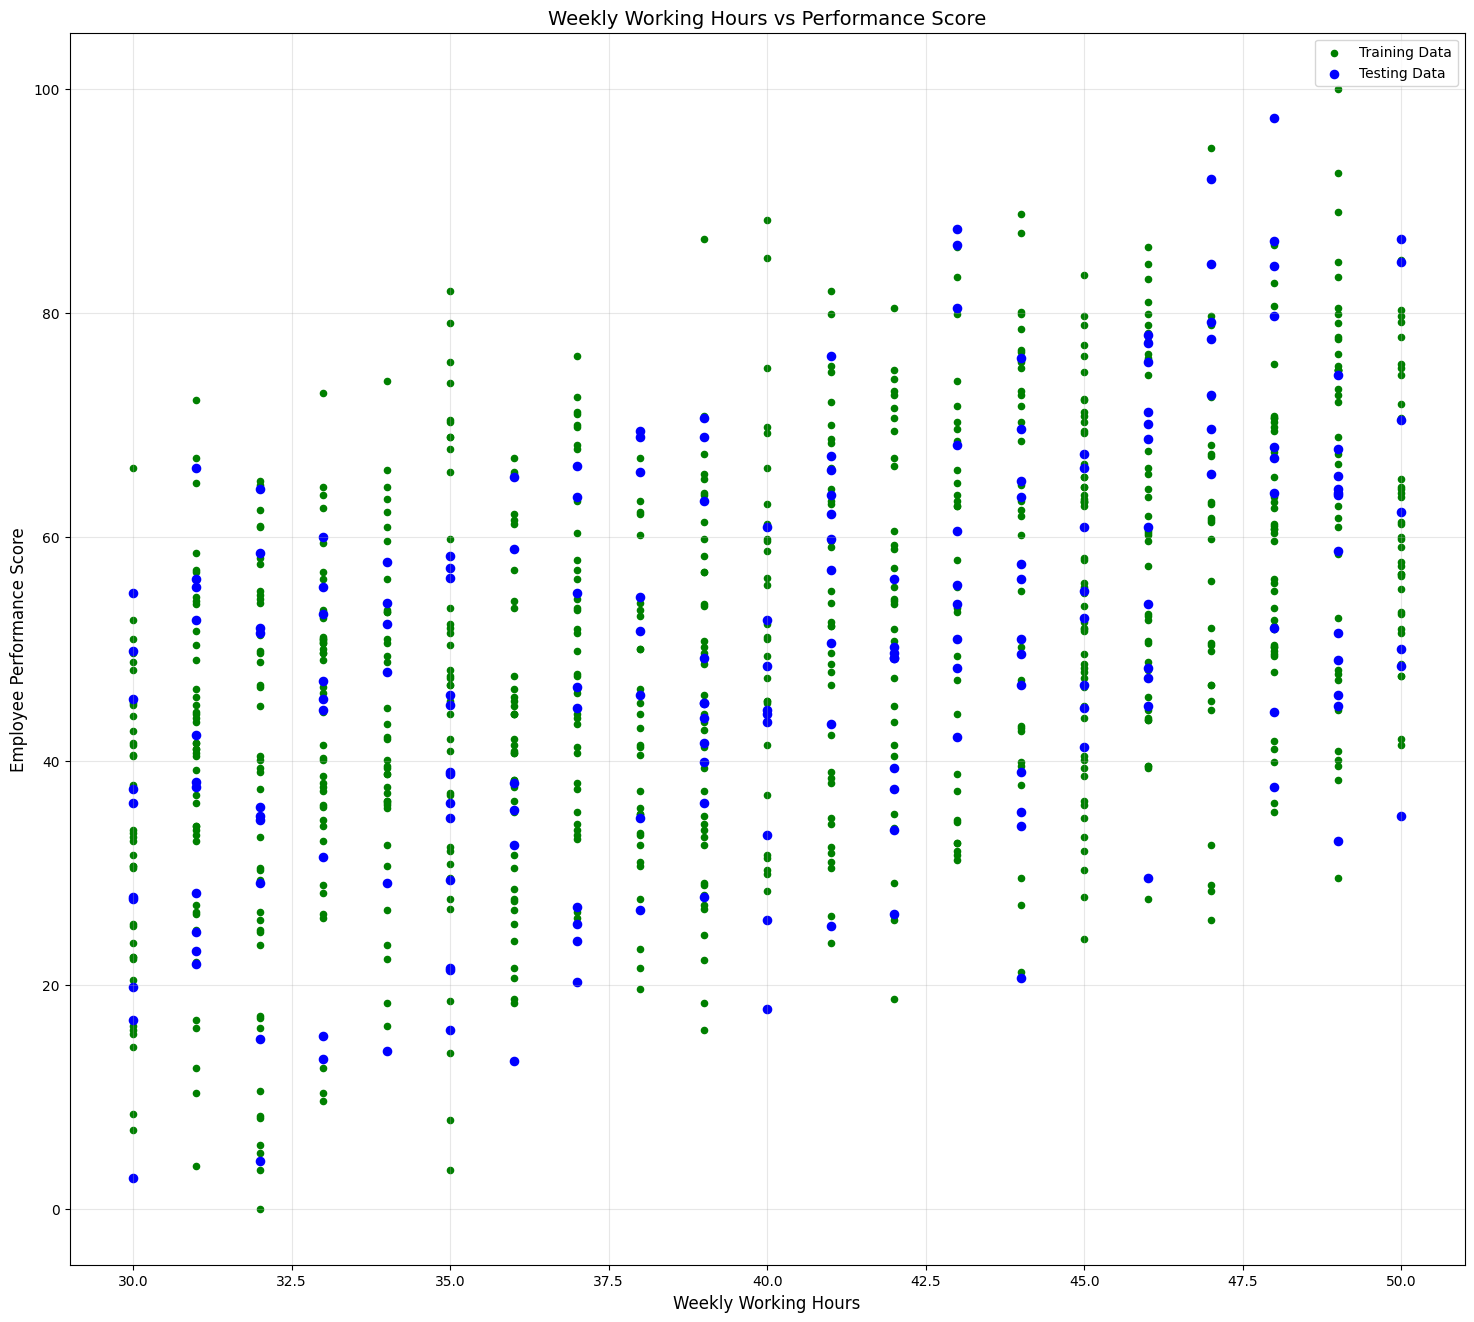

In [14]:
feature_names = [
    "Attendance (%)",
    "Experience (Years)",
    "Current Projects",
    "Completed Projects",
    "Weekly Working Hours"
]

def dataset_intuition(
    feature_index=0,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    predictions=None
):
    plt.figure(figsize=(18, 16))

    plt.scatter(
        x_train[:, feature_index],
        y_train,
        color="green",
        s=20,
        label="Training Data"
    )

    plt.scatter(
        x_test[:, feature_index],
        y_test,
        color="blue",
        s=35,
        label="Testing Data"
    )

    if predictions is not None:
        plt.scatter(
            x_test[:, feature_index],
            predictions,
            color="red",
            s=20,
            label="Predictions"
        )

    plt.xlabel(feature_names[feature_index], fontsize=12)
    plt.ylabel("Employee Performance Score", fontsize=12)
    plt.title(f"{feature_names[feature_index]} vs Performance Score", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    
dataset_intuition(4)

In [15]:
class PerformanceScorePredictorModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(5,1), requires_grad=True)        
        self.bias = nn.Parameter(torch.rand(1), requires_grad=True)        
        
    def forward(self, X:torch.Tensor):
        return torch.matmul(X, self.weights) + self.bias

In [16]:
torch.manual_seed(42)
model = PerformanceScorePredictorModel()
print(model.state_dict())

OrderedDict({'weights': tensor([[ 0.3367],
        [ 0.1288],
        [ 0.2345],
        [ 0.2303],
        [-1.1229]]), 'bias': tensor([0.8694])})


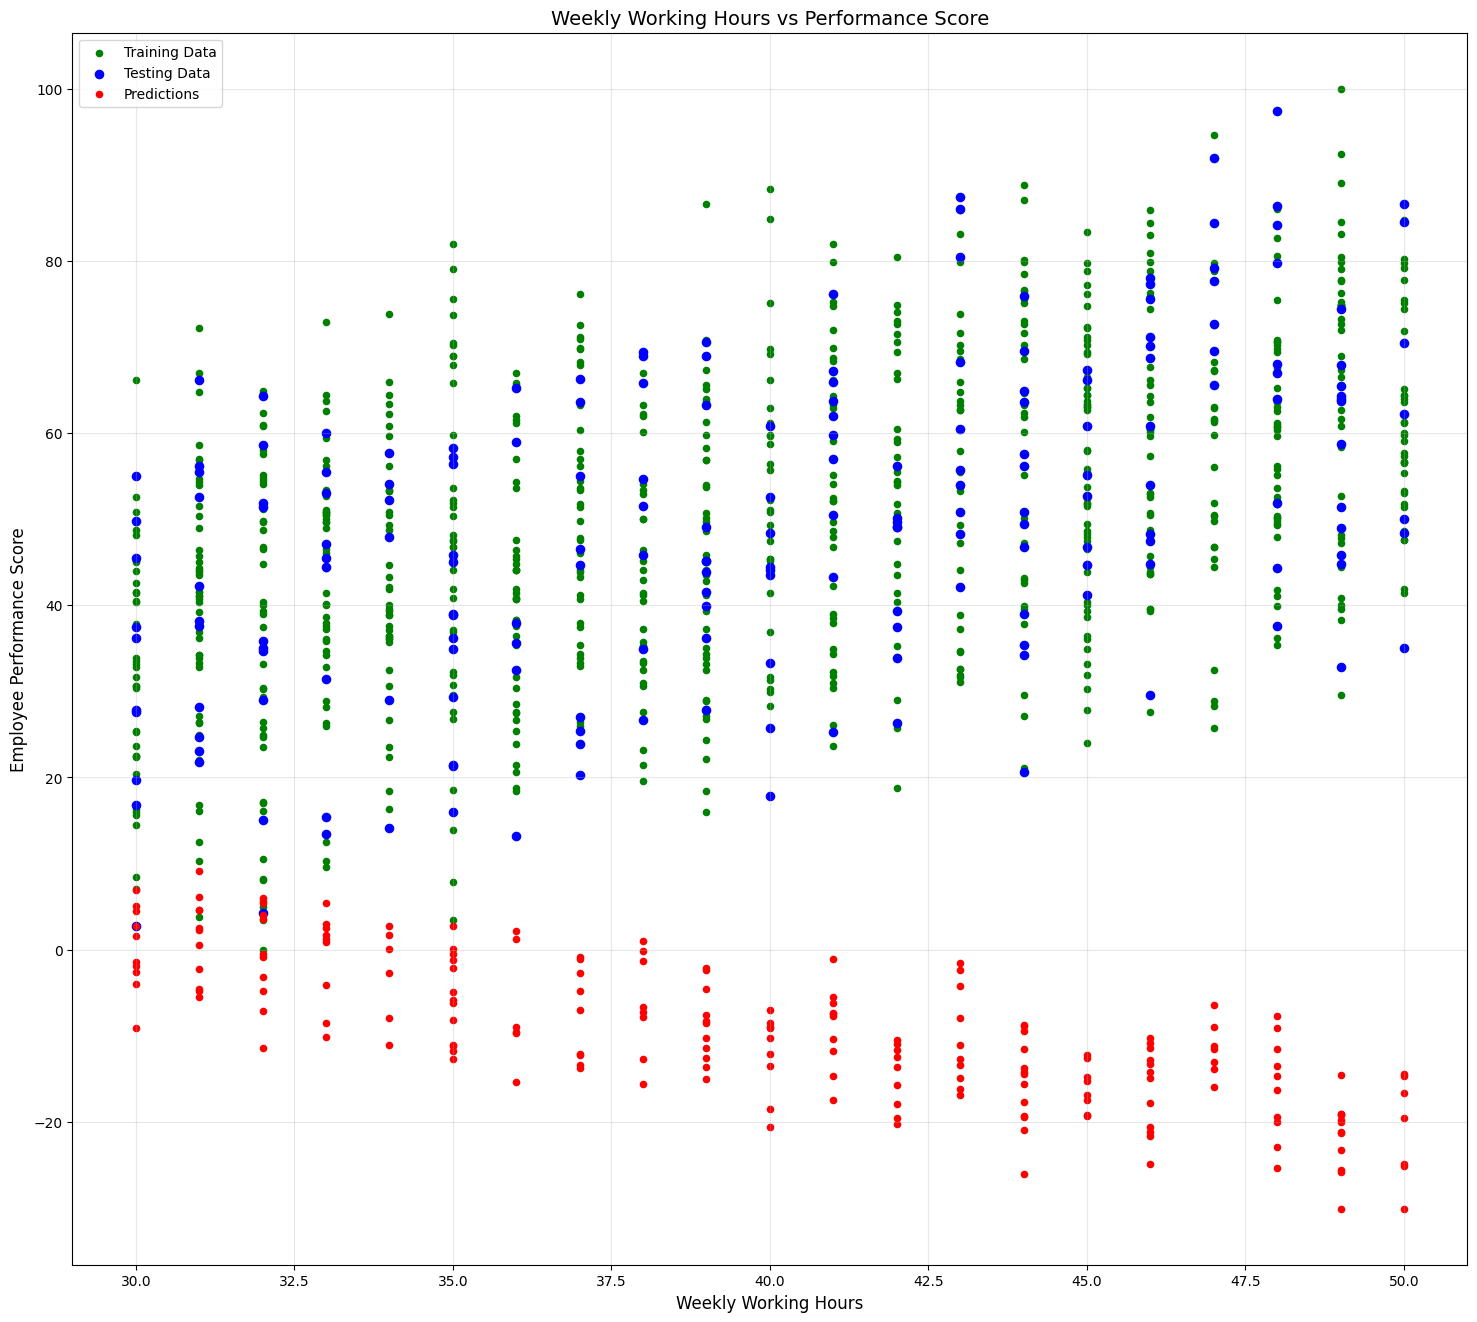

In [17]:
with torch.inference_mode():
    ypred = model(x_test)
ypred
dataset_intuition(feature_index=4,predictions=ypred)

In [18]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

In [19]:
epochs = 25000

for epoch in range(epochs):
    model.train()
    
    model_predictions = model(x_train)
    train_loss = loss_fn(model_predictions,y_train)
    
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    model.eval()
    
    if epoch % 10 == 0:                        
        print(f"Epoch number: {epoch + 1 } | MAE Train Loss: {train_loss} ")
        
        
    

Epoch number: 1 | MAE Train Loss: 3861.01806640625 
Epoch number: 11 | MAE Train Loss: 2214.81689453125 
Epoch number: 21 | MAE Train Loss: 1113.6446533203125 
Epoch number: 31 | MAE Train Loss: 507.4751892089844 
Epoch number: 41 | MAE Train Loss: 255.0764617919922 
Epoch number: 51 | MAE Train Loss: 187.8749237060547 
Epoch number: 61 | MAE Train Loss: 182.2694549560547 
Epoch number: 71 | MAE Train Loss: 183.7744140625 
Epoch number: 81 | MAE Train Loss: 182.2263641357422 
Epoch number: 91 | MAE Train Loss: 180.1285400390625 
Epoch number: 101 | MAE Train Loss: 178.86293029785156 
Epoch number: 111 | MAE Train Loss: 178.0319366455078 
Epoch number: 121 | MAE Train Loss: 177.2115478515625 
Epoch number: 131 | MAE Train Loss: 176.33937072753906 
Epoch number: 141 | MAE Train Loss: 175.4497528076172 
Epoch number: 151 | MAE Train Loss: 174.5488739013672 
Epoch number: 161 | MAE Train Loss: 173.6318817138672 
Epoch number: 171 | MAE Train Loss: 172.69915771484375 
Epoch number: 181 | MA

OrderedDict({'weights': tensor([[0.8591],
        [1.5464],
        [0.5155],
        [0.6873],
        [1.3746]]), 'bias': tensor([-101.3745])})
Actual weights:  tensor([[0.5000],
        [0.9000],
        [0.3000],
        [0.4000],
        [0.8000]])
Actual bias:  0.4
tensor([[53.0945],
        [62.2011],
        [15.9807],
        [59.9675],
        [60.4829],
        [32.4757],
        [80.4145],
        [65.9813],
        [47.9399],
        [48.9707],
        [91.9266],
        [87.4592],
        [52.2354],
        [24.7438],
        [70.4486],
        [65.8095],
        [60.8265],
        [65.6376],
        [64.2630],
        [54.9846],
        [44.6751],
        [64.2631],
        [39.3486],
        [41.2387],
        [63.9193],
        [68.9023],
        [33.8503],
        [63.9193],
        [76.1189],
        [66.3250],
        [63.7476],
        [55.1564],
        [57.2184],
        [58.9366],
        [56.3592],
        [46.7371],
        [56.1873],
        [26.9774],
      

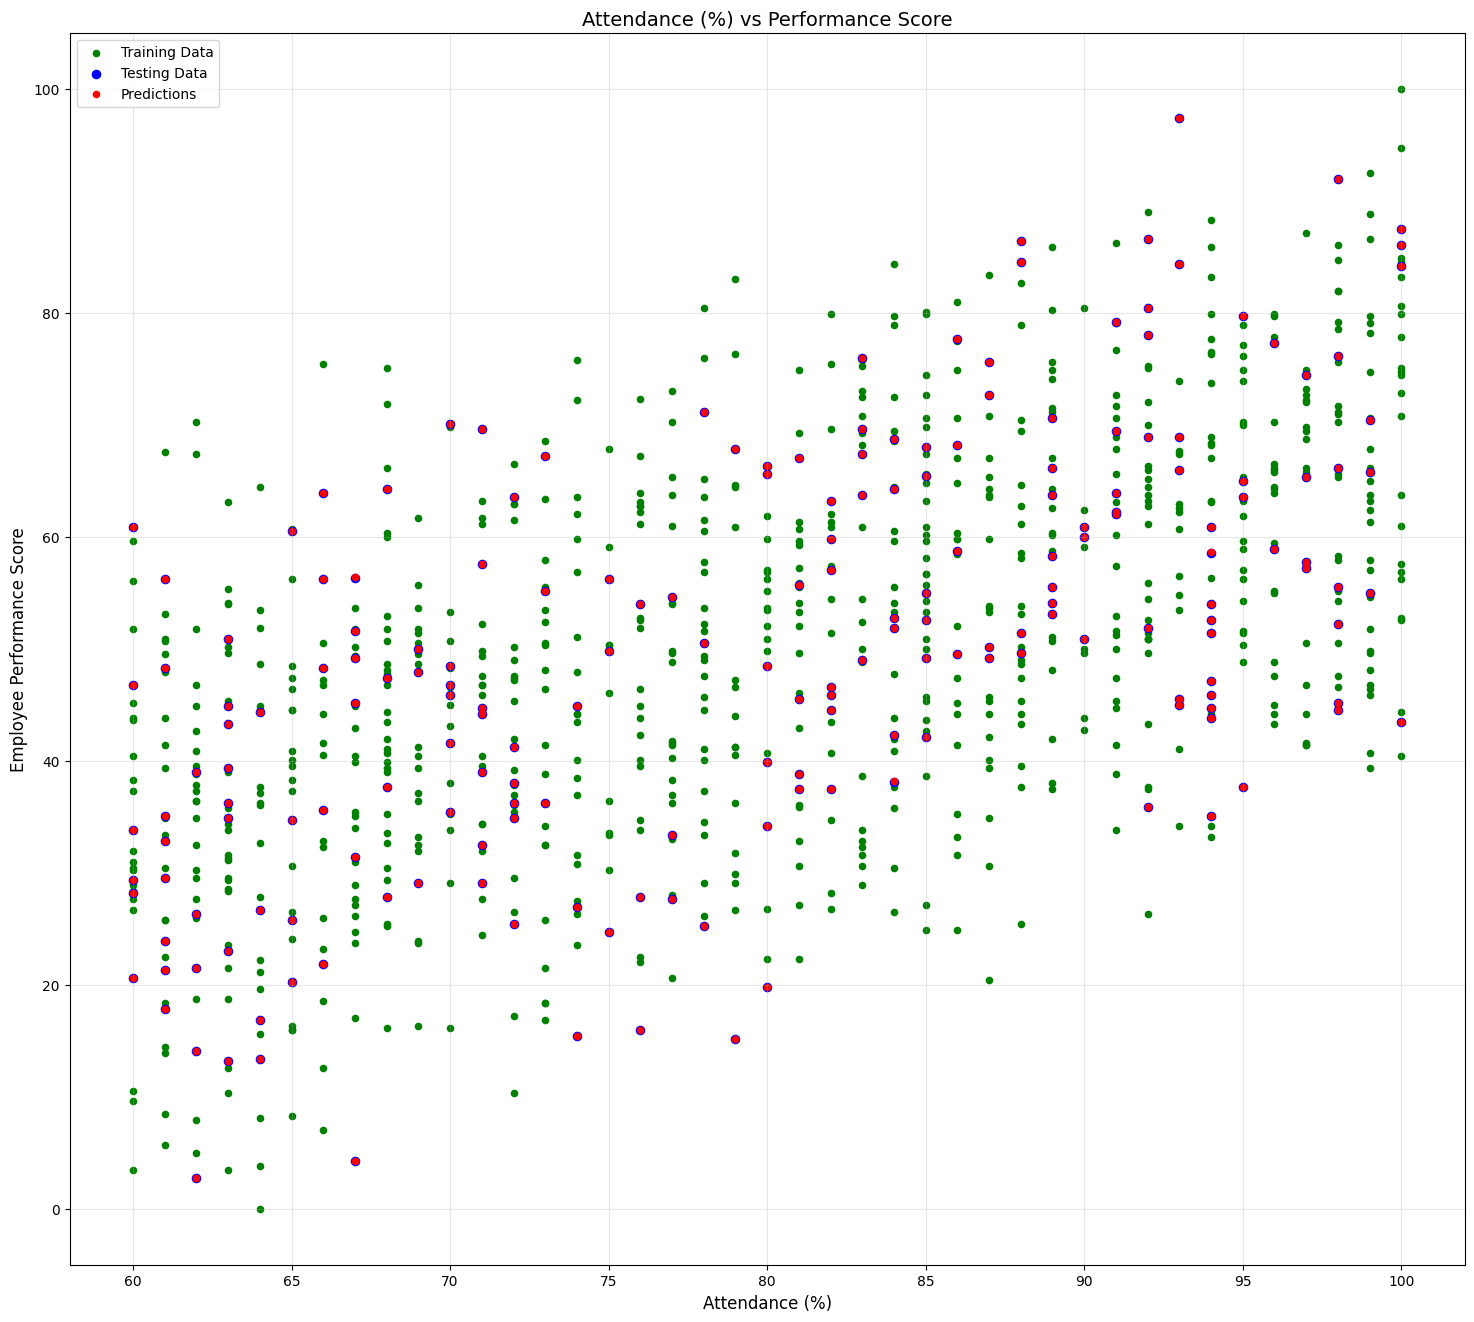

In [21]:
with torch.inference_mode():
    test_pred = model(x_test)
print(model.state_dict())
print(f"Actual weights: " , weights)
print(f"Actual bias: " , bias)
print(test_pred)
dataset_intuition(feature_index=0,predictions=test_pred)